In [1]:
import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
RAW_CAFE_PATH = "../raw/소상공인시장진흥공단_개인카페_포항.csv"
RAW_ACCOM_PATH = "../raw/상권(숙박)정보_포항시.csv"
SAVE_250_PATH = "../data/포항_카페_숙박상권 250m.csv"
SAVE_500_PATH = "../data/포항_카페_숙박상권 500m.csv"

df_cafe = pd.read_csv(RAW_CAFE_PATH, encoding="utf-8")
df_accom = pd.read_csv(RAW_ACCOM_PATH, header=None)

### 데이터 전처리

In [4]:
def find_coord_cols(df):
    lon_col, lat_col = None, None
    for col in df.columns:
        val = pd.to_numeric(df[col], errors='coerce').mean()
        if 128 < val < 130: lon_col = col
        elif 35 < val < 37: lat_col = col
    return lon_col, lat_col

lon_idx, lat_idx = find_coord_cols(df_accom)

df_cafe['lon'] = pd.to_numeric(df_cafe['lon'], errors='coerce')
df_cafe['lat'] = pd.to_numeric(df_cafe['lat'], errors='coerce')
df_accom['lon'] = pd.to_numeric(df_accom[lon_idx], errors='coerce')
df_accom['lat'] = pd.to_numeric(df_accom[lat_idx], errors='coerce')

# 결측치 제거
df_cafe = df_cafe.dropna(subset=['lon', 'lat']).reset_index(drop=True)
df_accom = df_accom.dropna(subset=['lon', 'lat']).reset_index(drop=True)

# GeoDataFrame 생성 (WGS84)
gdf_cafe = gpd.GeoDataFrame(
    df_cafe, 
    geometry=gpd.points_from_xy(df_cafe['lon'], df_cafe['lat']),
    crs="EPSG:4326"
)

gdf_accom = gpd.GeoDataFrame(
    df_accom, 
    geometry=gpd.points_from_xy(df_accom['lon'], df_accom['lat']),
    crs="EPSG:4326"
)

# 미터 단위 좌표계(EPSG:5179) 변환
gdf_cafe_5179 = gdf_cafe.to_crs("EPSG:5179")
gdf_accom_5179 = gdf_accom.to_crs("EPSG:5179")

### 거리 지정

In [5]:
distance = 250

### 컬럼 추가 후 파일 저장

In [6]:
# 카운트 함수
def count_within_radius(target_gdf, poi_gdf, radius):
    # 버퍼 생성
    target_buffer = target_gdf.copy()
    target_buffer['geometry'] = target_buffer.geometry.buffer(radius)

    # 공간 결합
    joined = gpd.sjoin(poi_gdf, target_buffer, how='inner', predicate='within')

    # 숙박업소 개수 카운트
    return joined.index_right.value_counts()

# 실행 및 거리별 개별 저장
col_name = "숙박업소수"
print("--- %dm 반경 분석 시작 ---" % distance)

counts = count_within_radius(gdf_cafe_5179, gdf_accom_5179, distance)

df_result = df_cafe.copy()
df_result[col_name] = df_result.index.map(counts).fillna(0).astype(int)

df_result.drop(columns=['geometry'], errors='ignore').to_csv(SAVE_250_PATH, index=False, encoding='utf-8-sig')
print("--- 저장 완료 ---")

--- 250m 반경 분석 시작 ---
--- 저장 완료 ---


In [7]:
distance = 500

In [8]:
# 카운트 함수
def count_within_radius(target_gdf, poi_gdf, radius):
    # 버퍼 생성
    target_buffer = target_gdf.copy()
    target_buffer['geometry'] = target_buffer.geometry.buffer(radius)

    # 공간 결합
    joined = gpd.sjoin(poi_gdf, target_buffer, how='inner', predicate='within')

    # 숙박업소 개수 카운트
    return joined.index_right.value_counts()

# 실행 및 거리별 개별 저장
col_name = "숙박업소수"
print("--- %dm 반경 분석 시작 ---" % distance)

counts = count_within_radius(gdf_cafe_5179, gdf_accom_5179, distance)

df_result = df_cafe.copy()
df_result[col_name] = df_result.index.map(counts).fillna(0).astype(int)

df_result.drop(columns=['geometry'], errors='ignore').to_csv(SAVE_500_PATH, index=False, encoding='utf-8-sig')
print("--- 저장 완료 ---")

--- 500m 반경 분석 시작 ---
--- 저장 완료 ---


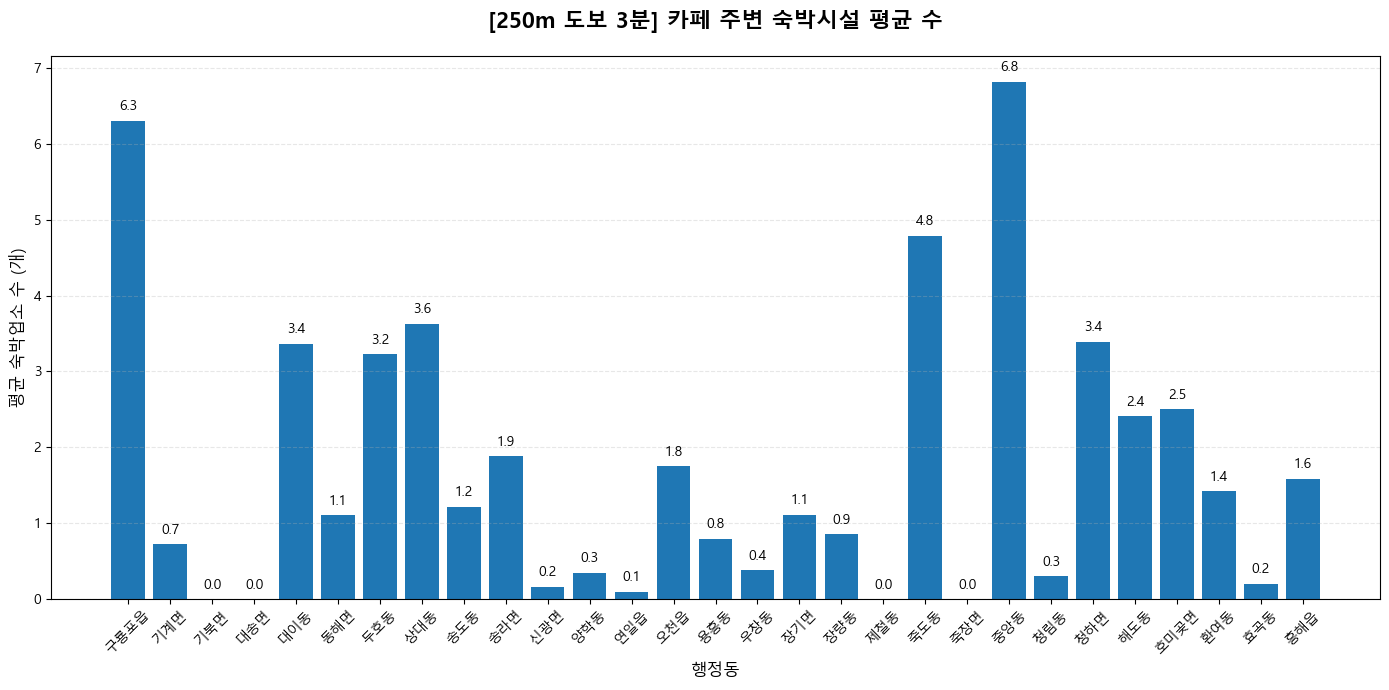

In [18]:
# 1. 데이터 불러오기
df_250 = pd.read_csv(SAVE_250_PATH, encoding='utf-8-sig')

# 2. 행정동별 평균 숙박업소 수 계산 (상위 15개)
# 세로 막대에서는 왼쪽에서 오른쪽으로 큰 값이 오도록 정렬된 상태 그대로 사용합니다.
dong_250 = df_250.groupby('행정동명')['숙박업소수'].mean().reset_index()

# 3. 그래프 그리기 (plt.bar 사용)
plt.figure(figsize=(14, 7))

# bar가 세로 막대 그래프 함수입니다.
bars = plt.bar(dong_250['행정동명'], dong_250['숙박업소수'])

# 제목 및 라벨 설정
plt.title('[250m 도보 3분] 카페 주변 숙박시설 평균 수', fontsize=16, pad=20, fontweight='bold')
plt.ylabel('평균 숙박업소 수 (개)', fontsize=12)
plt.xlabel('행정동', fontsize=12)

# x축 글자가 겹칠 수 있으므로 45도 회전
plt.xticks(rotation=45)

# 막대 위에 수치 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height:.1f}', ha='center', va='bottom', fontsize=10)

# 가로 그리드 추가 (세로 막대일 때는 가로선이 가독성이 좋음)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig("카페 주변 숙박시설 평균 수.png")
plt.show()

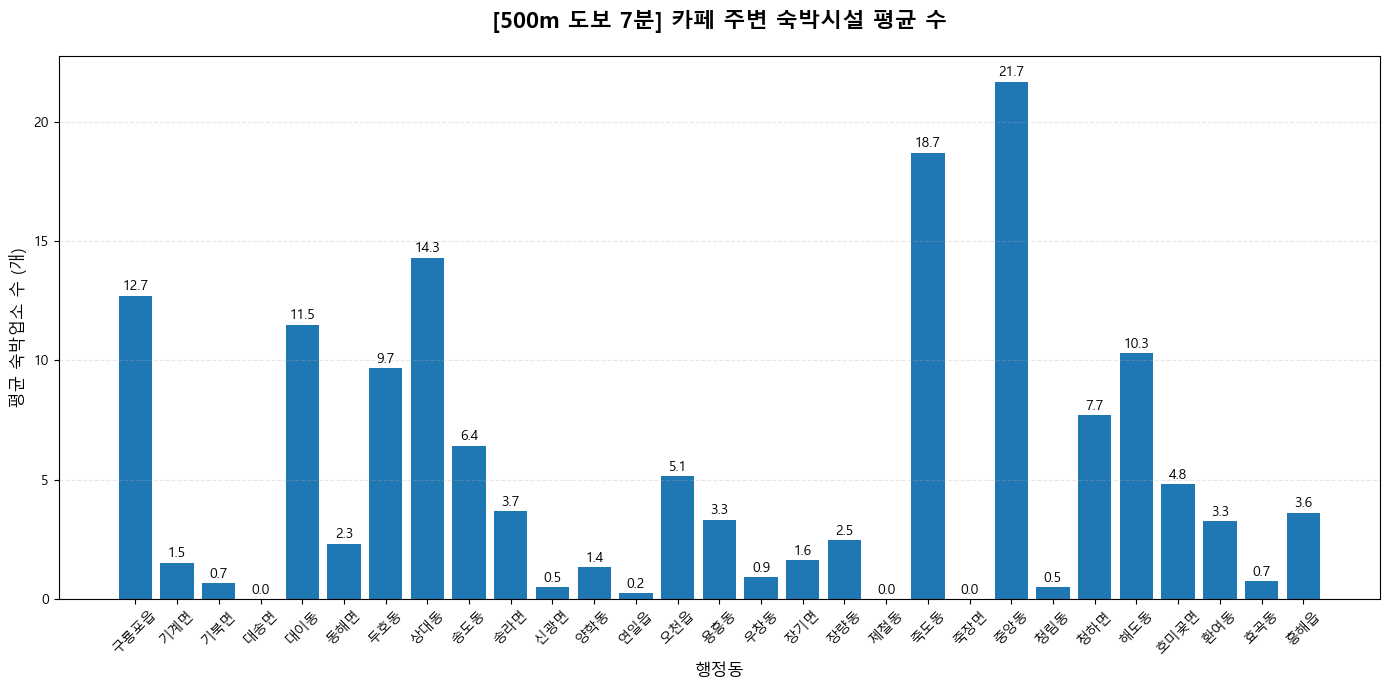

In [20]:
# 1. 데이터 불러오기
df_500 = pd.read_csv(SAVE_500_PATH, encoding='utf-8-sig')

# 2. 행정동별 평균 숙박업소 수 계산 (상위 15개)
# 세로 막대에서는 왼쪽에서 오른쪽으로 큰 값이 오도록 정렬된 상태 그대로 사용합니다.
dong_500 = df_500.groupby('행정동명')['숙박업소수'].mean().reset_index()

# 3. 그래프 그리기 (plt.bar 사용)
plt.figure(figsize=(14, 7))

# bar가 세로 막대 그래프 함수입니다.
bars = plt.bar(dong_500['행정동명'], dong_500['숙박업소수'])

# 제목 및 라벨 설정
plt.title('[500m 도보 7분] 카페 주변 숙박시설 평균 수', fontsize=16, pad=20, fontweight='bold')
plt.ylabel('평균 숙박업소 수 (개)', fontsize=12)
plt.xlabel('행정동', fontsize=12)

# x축 글자가 겹칠 수 있으므로 45도 회전
plt.xticks(rotation=45)

# 막대 위에 수치 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height:.1f}', ha='center', va='bottom', fontsize=10)

# 가로 그리드 추가 (세로 막대일 때는 가로선이 가독성이 좋음)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig("카페 주변 숙박시설 평균 수.png")
plt.show()